# **# Assignment 10: Support Vector Machine (Drug Response Classification - Pharma_Industry_2.csv)**

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# **Task 1: Exploratory Data Analysis (EDA)**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None

--- Summary Statistics ---
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          

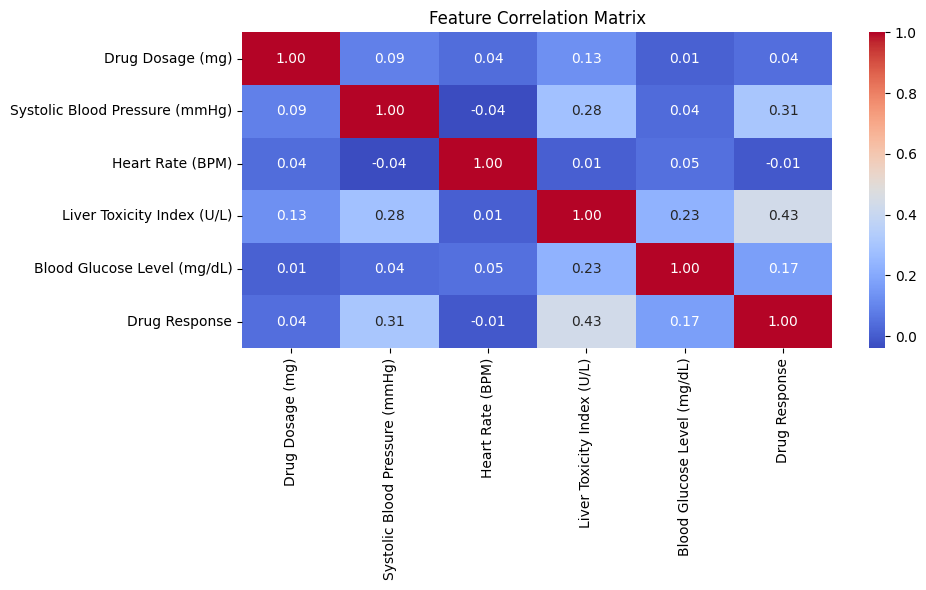

In [19]:
# Load dataset
df = pd.read_csv("/content/Pharma_Industry.csv")

print("--- Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# Check missing values
print("\nMissing Values Count:\n", df.isnull().sum())

# Feature Correlations[cite: 13]
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# **Task 2: Data Preprocessing**

In [20]:
# Features and Target
X = df.drop(columns=["Drug Response"])
y = df["Drug Response"]

# Train-Test Split (80% Train, 20% Test)[cite: 13]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Task 3: Data Visualization**

/tmp/ipykernel_4462/2842792873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Drug Response", data=df, palette="Set1")


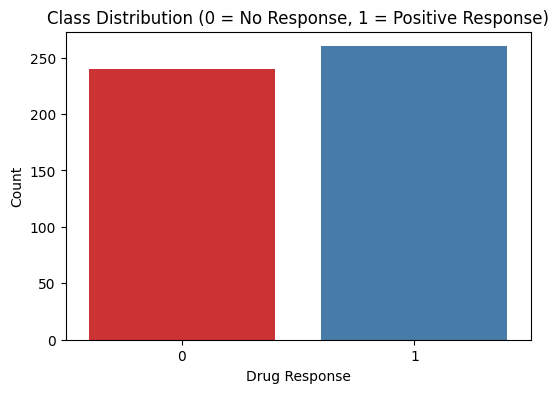

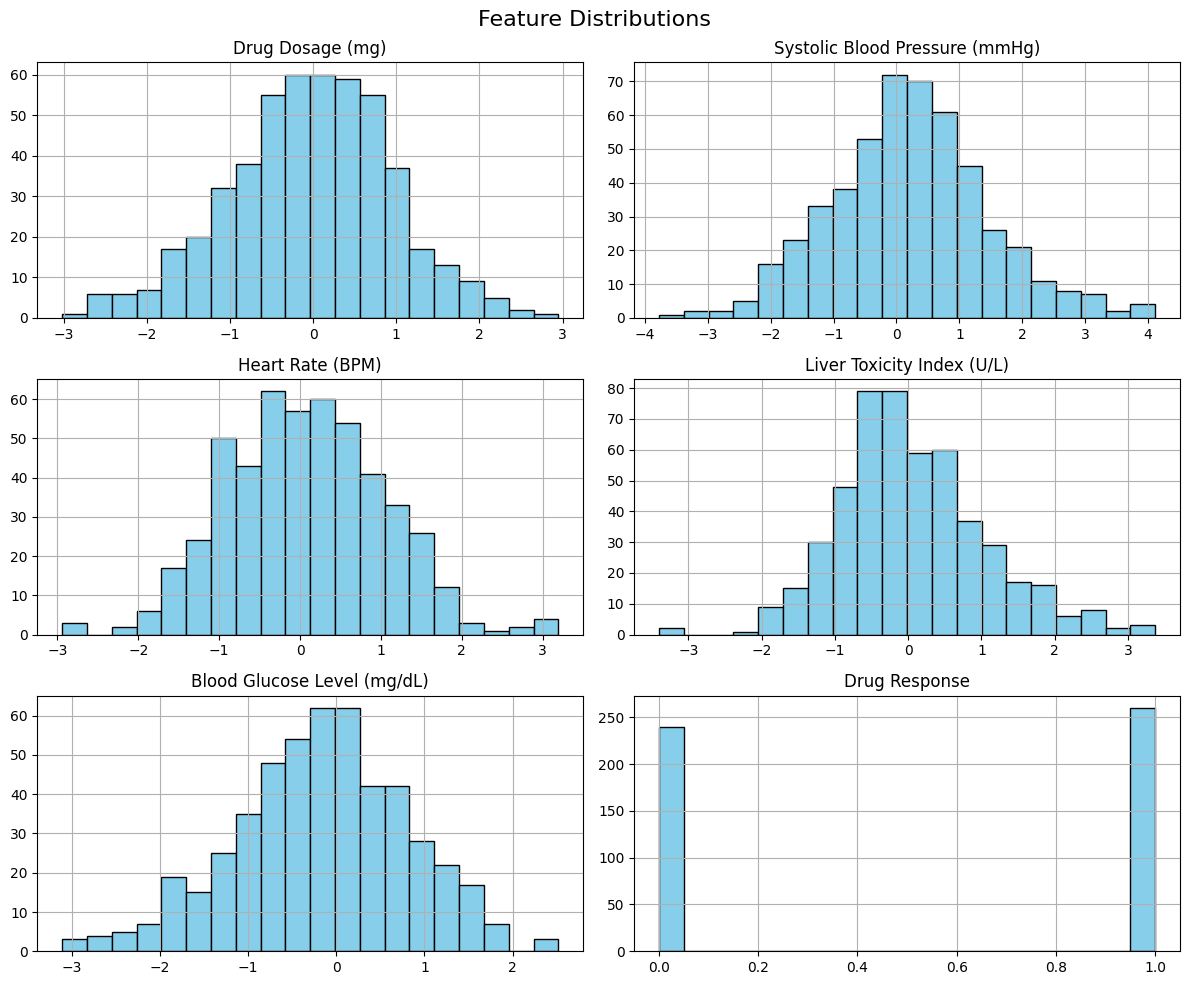

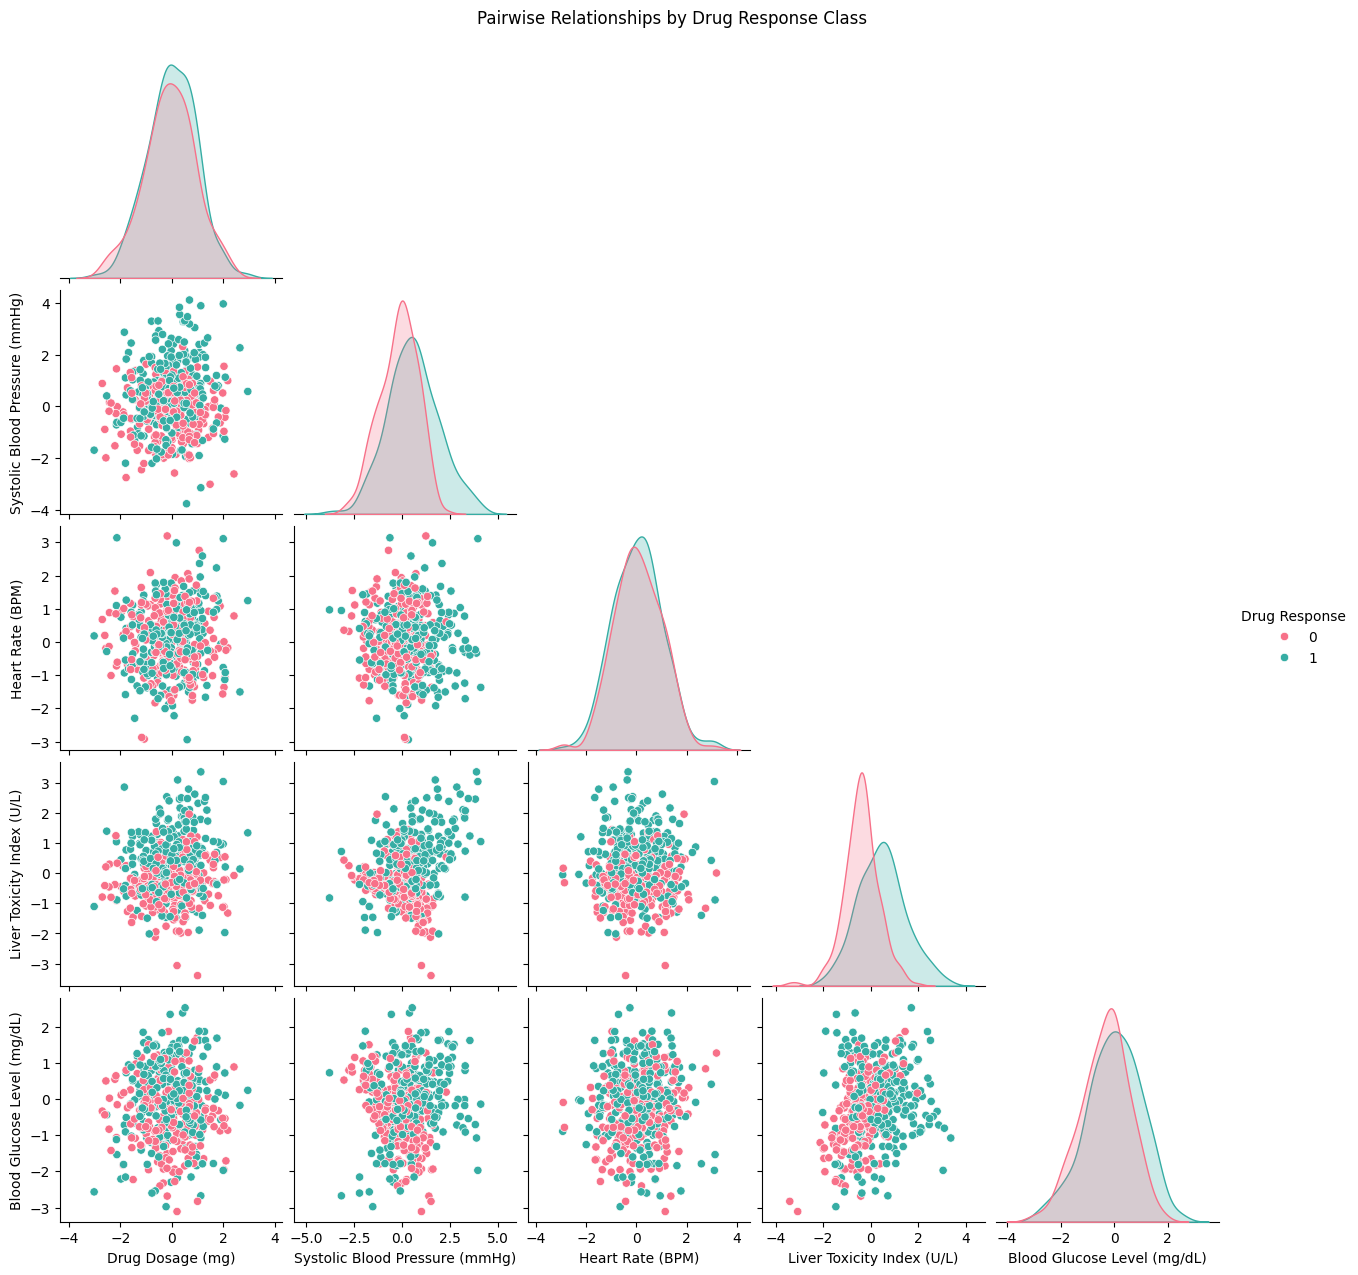

In [15]:
# Visualizing Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Drug Response", data=df, palette="Set1")
plt.title("Class Distribution (0 = No Response, 1 = Positive Response)")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.show()

# Feature Distributions
df.hist(figsize=(12, 10), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Pairwise Relationships[cite: 13]
sns.pairplot(df, hue="Drug Response", palette="husl", corner=True)
plt.suptitle("Pairwise Relationships by Drug Response Class", y=1.02)
plt.show()

# **Task 4 & 5: SVM Implementation & Result Visualizations**

--- Baseline SVM Model Evaluation ---
Accuracy : 0.77
Precision: 0.7543859649122807
Recall   : 0.8269230769230769
F1-Score : 0.7889908256880734


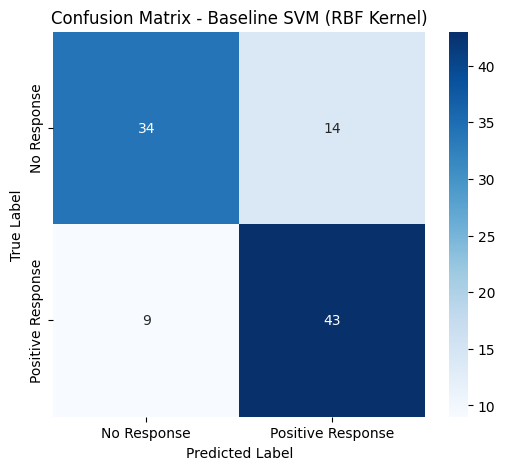

In [21]:
# Train Baseline SVM Classifier (RBF Kernel)
svm_base = SVC(kernel="rbf", random_state=42)
svm_base.fit(X_train_scaled, y_train)

y_pred_base = svm_base.predict(X_test_scaled)

print("--- Baseline SVM Model Evaluation ---")
print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base))
print("Recall   :", recall_score(y_test, y_pred_base))
print("F1-Score :", f1_score(y_test, y_pred_base))

# Confusion Matrix[cite: 13]
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response", "Positive Response"],
    yticklabels=["No Response", "Positive Response"],
)
plt.title("Confusion Matrix - Baseline SVM (RBF Kernel)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **Task 6: Parameter Tuning and Optimization**

In [22]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "poly", "linear"],
}

grid_search = GridSearchCV(
    SVC(random_state=42), param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("\n--- Hyperparameter Tuning Results ---")
print("Best Parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_

y_pred_opt = best_svm.predict(X_test_scaled)
print("\n--- Optimized SVM Model Performance ---")
print(classification_report(y_test, y_pred_opt))


--- Hyperparameter Tuning Results ---
Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}

--- Optimized SVM Model Performance ---
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        48
           1       0.71      0.77      0.74        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



# **Task 7: Comparison across Kernels & Business Analysis**

In [23]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
kernel_results = []

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    kernel_results.append(
        {
            "Kernel": k.capitalize(),
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds),
            "Recall": recall_score(y_test, preds),
            "F1-Score": f1_score(y_test, preds),
        }
    )

kernel_df = pd.DataFrame(kernel_results)
print("\n--- SVM Kernel Performance Comparison ---")
print(kernel_df.to_string(index=False))


--- SVM Kernel Performance Comparison ---
 Kernel  Accuracy  Precision   Recall  F1-Score
 Linear      0.72   0.760870 0.673077  0.714286
   Poly      0.65   0.666667 0.653846  0.660194
    Rbf      0.77   0.754386 0.826923  0.788991
Sigmoid      0.73   0.755102 0.711538  0.732673
